# 📌 Spam Email Detection Project

## 📖 Introduction (Markdown Cell)
Email communication is widely used but vulnerable to **spam messages** that waste time and may contain phishing or malware. Detecting spam automatically improves security and efficiency.  

In this project, we use **Natural Language Processing (NLP)** and **Machine Learning** to classify emails as **spam** or **ham (not spam)**. We apply **TF-IDF vectorization** and compare two models: **Naive Bayes** and **Logistic Regression**. Evaluation is done with **accuracy, precision, recall, and confusion matrices**.



# 📌 Spam Email Detection Project

## 📖 Introduction (Markdown Cell)
Email communication is widely used but vulnerable to **spam messages** that waste time and may contain phishing or malware. Detecting spam automatically improves security and efficiency.  

In this project, we use **Natural Language Processing (NLP)** and **Machine Learning** to classify emails as **spam** or **ham (not spam)**. We apply **TF-IDF vectorization** and compare two models: **Naive Bayes** and **Logistic Regression**. Evaluation is done with **accuracy, precision, recall, and confusion matrices**.



In [1]:
!pip install matplotlib


  Using cached matplotlib-3.10.6-cp313-cp313-win_amd64.whl.metadata (11 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------------- - 7.9/8.1 MB 52.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 45.4 MB/s eta 0:00:00


In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [3]:
# Load dataset
df = pd.read_csv("spam.csv", encoding="latin-1")[['v1', 'v2']]
df.columns = ["label", "message"]
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5572, 2)
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


- The dataset contains SMS messages labeled as **spam** or **ham**.  
- Labels are mapped to binary values (0 = ham, 1 = spam).  

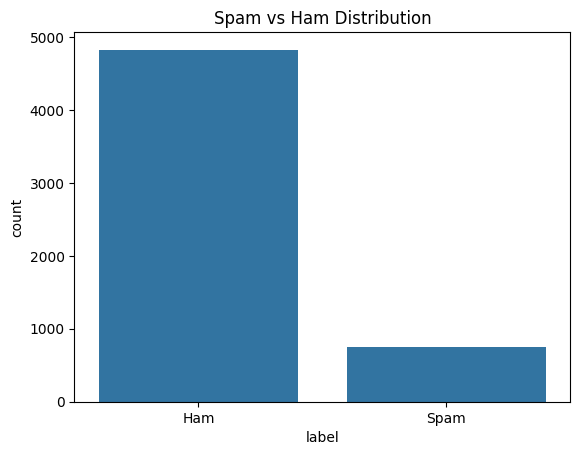

In [4]:
# Label Distribution
sns.countplot(x=df['label'])
plt.title("Spam vs Ham Distribution")
plt.xticks([0, 1], ["Ham", "Spam"])
plt.show()

- The dataset is imbalanced: more ham messages than spam.  
- This imbalance can affect model performance.  

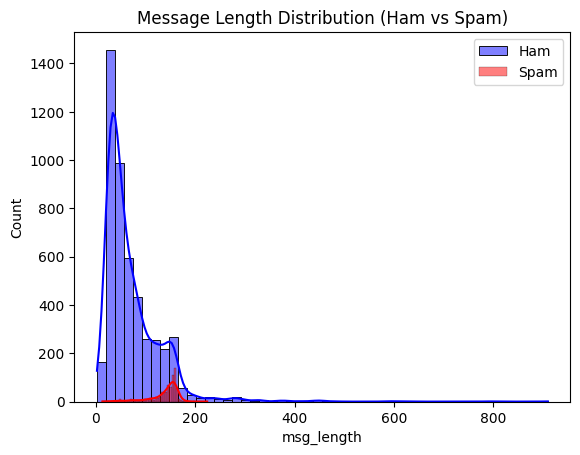

In [5]:
# Message Length Distribution

df['msg_length'] = df['message'].apply(len)
sns.histplot(df[df['label']==0]['msg_length'], bins=50, color='blue', label='Ham', kde=True)
sns.histplot(df[df['label']==1]['msg_length'], bins=50, color='red', label='Spam', kde=True)
plt.legend()
plt.title("Message Length Distribution (Ham vs Spam)")
plt.show()

- Spam messages tend to be longer, containing offers, links, and promotional text.  
- Ham messages are often shorter and conversational.  

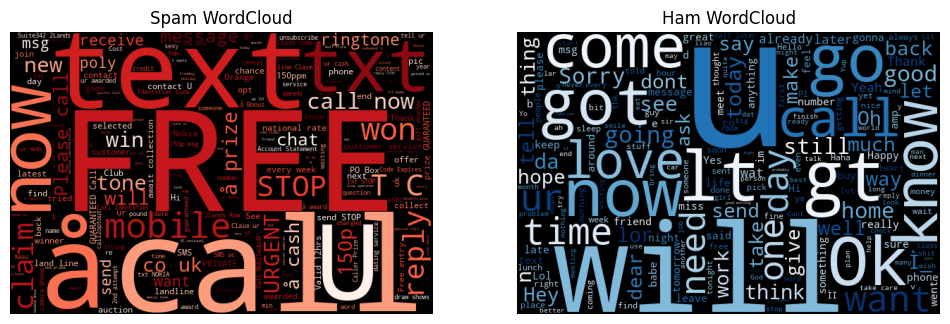

In [6]:
# Word Clouds

spam_words = ' '.join(list(df[df['label']==1]['message']))
ham_words = ' '.join(list(df[df['label']==0]['message']))

spam_wc = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate(spam_words)
ham_wc = WordCloud(width=600, height=400, background_color='black', colormap='Blues').generate(ham_words)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(spam_wc)
plt.axis('off')
plt.title("Spam WordCloud")

plt.subplot(1,2,2)
plt.imshow(ham_wc)
plt.axis('off')
plt.title("Ham WordCloud")
plt.show()

- Spam word cloud highlights words like *free, win, congratulations, offer*.  
- Ham word cloud highlights casual/conversational words like *hey, today, meeting*. 

## ⚙️ Model Training

In [7]:
# Train/Test Split & Vectorization

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

- Train/test split ensures fair evaluation.  
- TF-IDF converts text into numerical features while ignoring common stop words. 

In [8]:
# Train Models

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_nb = nb_model.predict(X_test_vec)

print("Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:
Accuracy: 0.9721973094170404
Precision: 0.9916666666666667
Recall: 0.7986577181208053
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [9]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_vec, y_train)
y_pred_log = log_model.predict(X_test_vec)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Results:
Accuracy: 0.9704035874439462
Precision: 1.0
Recall: 0.7785234899328859
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



## 📈 Results

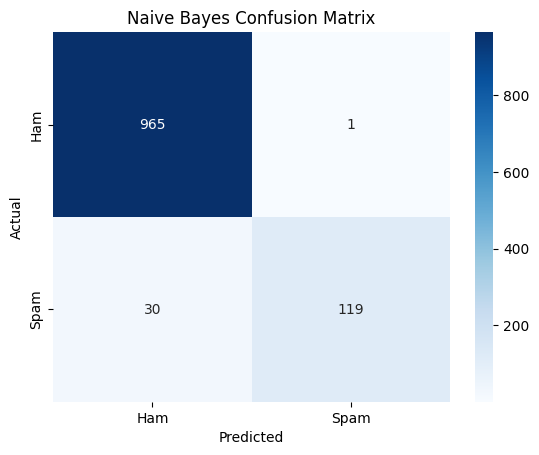

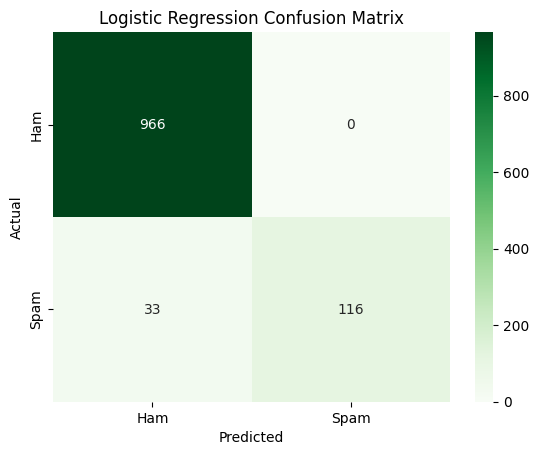

In [10]:
# Confusion Matrices

from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:

- Both models perform well with high accuracy.  
- Confusion matrices show most emails classified correctly.  
- False positives (ham marked as spam) are annoying, false negatives (spam marked as ham) are dangerous.  


## 🏆 Conclusion
- **Naive Bayes**: Simple, fast, very effective for text data.  
- **Logistic Regression**: Competitive performance, sometimes slightly better recall.  
- Both models are suitable for spam detection.  

**Future Work:** Try deep learning models (RNN, LSTM, Transformers) and handle class imbalance.


In [ ]:



```


---

## 🔮 Sample Predictions
```python
samples = [
    "Congratulations! You've won a free lottery ticket. Claim now!",
    "Hey, are we still meeting for lunch today?",
    "Urgent! Your account has been suspended. Reset password here.",
    "Don't forget to complete your Python homework."
]

for s in samples:
    vec = vectorizer.transform([s])
    pred = nb_model.predict(vec)[0]
    print(f"Message: {s}\nPrediction: {'Spam' if pred==1 else 'Ham'}\n")
```

